In [ ]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [4]:
workdir = '/g/data/if69/cj0591/GC26_energy_synoptics'
datadir = f'{workdir}/data/wind_capacity_factor'

In [55]:
year = 2018; month = 1
dmd = xr.open_dataset(f'{datadir}/wind_capacity_factor_van_der_Wiel_era5_hourly_{year}_Aus.nc')
dmd = dmd.rename({'lat': 'latitude', 'lon': 'longitude'})
#dmd = dmd.sel(time=f'{year}-{str(month).zfill(2)}')

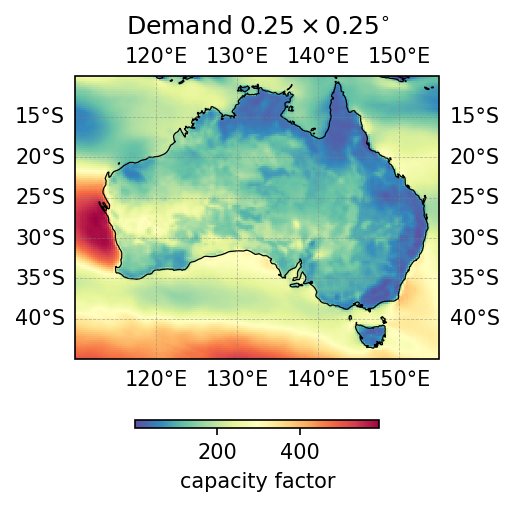

In [23]:
mapcrs  = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)
dmd.capacity_factor.sum('time').plot(
    ax=ax, transform=datacrs,
    cmap = 'Spectral_r',                         
    cbar_kwargs={"shrink": 0.3,
                "aspect": 30,
                "label": "capacity factor",
                "orientation": "horizontal"}
)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='k', lw=.6)
ax.set_extent([110, 155, -45, -10], crs=datacrs)
ax.set_title('Demand '+r'$0.25\times0.25^{\circ}$')
plt.show()

In [12]:
# interpolate the 0.25 to 0.5
# to match with weather object
lat_05 = np.arange(-10, -45-.5, -.5)
lon_05 = np.arange(110, 155+.5, .5)
dmd_05 = dmd.interp(latitude=lat_05, longitude=lon_05)

Text(0.5, 1.0, 'Demand $0.5\\times0.5^{\\circ}$')

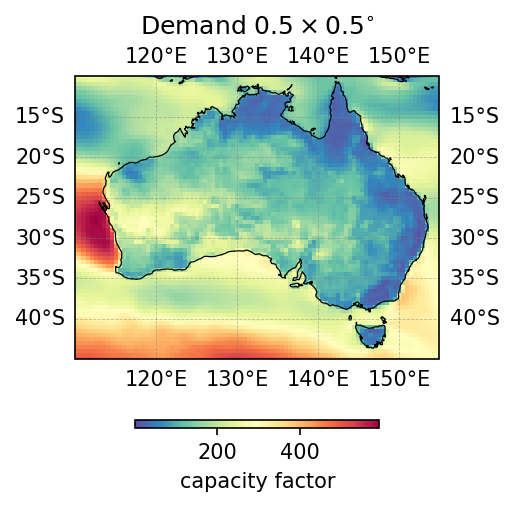

In [24]:
# plot interploated
mapcrs = ccrs.PlateCarree(central_longitude=120)
datacrs = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(7, 3.5),
    dpi=150, facecolor="w",
    subplot_kw={"projection": mapcrs},
)

dmd_05.capacity_factor.sum('time').plot(
    ax=ax, transform=datacrs,
    cmap = 'Spectral_r',                         
    cbar_kwargs={"shrink": 0.3,
                "aspect": 30,
                "label": "capacity factor",
                "orientation": "horizontal"}
)

gl = ax.gridlines(
    crs=datacrs,
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='k', lw=.6)
ax.set_extent([110, 155, -45, -10], crs=datacrs)
ax.set_title('Demand '+r'$0.5\times0.5^{\circ}$')

In [56]:
# box VIC
dmd_box_VIC = dmd.capacity_factor.sel(
    latitude=slice(-30, -35),
    longitude=slice(140, 150)
).sum(('latitude', 'longitude'))

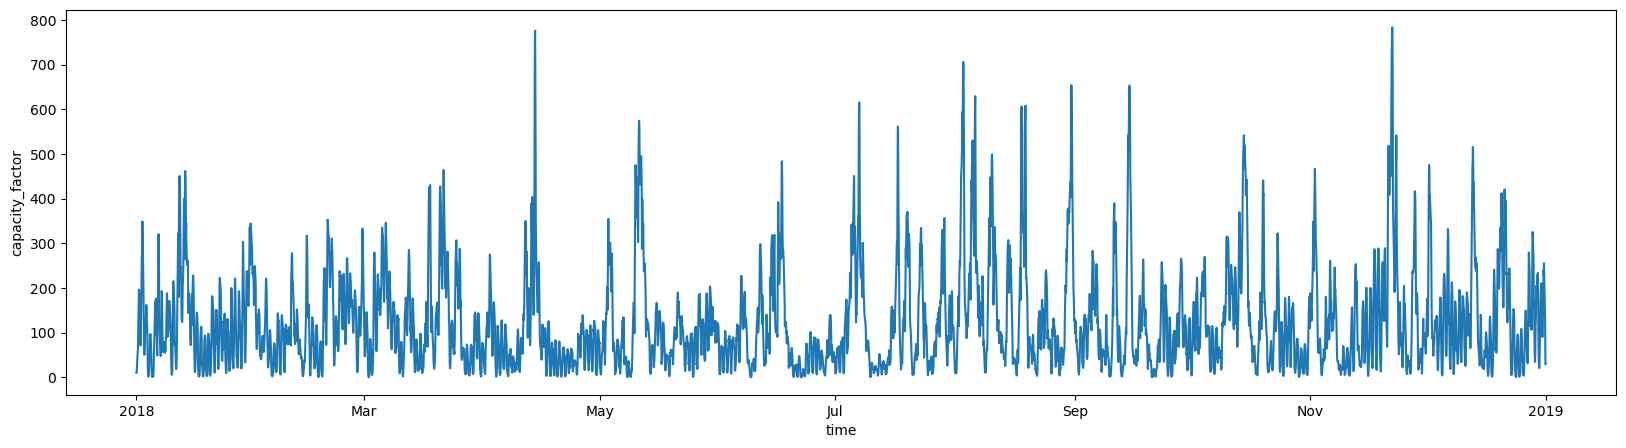

In [57]:
fig, ax1 = plt.subplots(figsize=(20, 5))
dmd_box_VIC.plot(ax=ax1)